In [2]:
from dace_query.sun import Sun
import matplotlib.pyplot as plt
from astropy.io import fits
import os
import numpy as np
import jdcal as j 
from astropy.time import Time
from pathlib import Path

import pandas as pd


In [3]:
data = pd.read_csv('/home/sophie-stucki/starsim/starsim/SDO_input/2015-2025/2015-2025/harpn_sun_release_timeseries_2015-2025.csv')


In [4]:
date = Time(np.array(data.bjd), format='jd', scale='tdb')
arg_sort = date.argsort()

rv = np.array(data.rv)[arg_sort] * 1e3
fwhm = np.array(data.fwhm)[arg_sort] * 1e3

# bis = np.array(data.spectro_ccf_bispan)[arg_sort]
# fwhm = np.array(data.spectro_ccf_fwhm_corr)[arg_sort]
# contrast = np.array(data.spectro_ccf_contrast)[arg_sort]

date = date[arg_sort]

In [5]:
t = Time(data.bjd + 2400000, format='jd', scale='tdb')

# Convert to UTC calendar date
t_utc = t.utc

print("UTC date:", t_utc.iso)

UTC date: ['2015-07-16 10:44:16.880' '2015-07-16 10:49:40.319'
 '2015-07-16 10:55:04.201' ... '2025-05-08 14:24:26.482'
 '2025-05-08 14:35:13.894' '2025-05-08 14:40:37.884']


In [22]:
start_time = j.gcal2jd(2015,7,1)[1] + 2400000.5
end_time = j.gcal2jd(2018,7,1)[1] + 2400000.5

date_harps = []
date_harps_fits = []

rv_harps = []
bis_harps = []
fwhm_harps = []
contrast_harps = []

for i in range(len(date)):
    if t_utc.jd[i] >= start_time and t_utc.jd[i] <= end_time:

        date_harps.append(t_utc[i])
        date_harps_fits.append(t_utc[i].to_value('iso', 'date'))

        rv_harps.append(rv[i])
        # bis_harps.append(bis[i])
        fwhm_harps.append(fwhm[i])
        # contrast_harps.append(contrast[i])

print(date_harps_fits)

['2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-16', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015-07-29', '2015

In [23]:
data_test = pd.DataFrame({'date': date_harps_fits,
             'rv': rv_harps,
             'fwhm': fwhm_harps})
            #  'contrast': contrast_harps})

# daily_avg = data_test.groupby('date')[['rv', 'bis', 'fwhm', 'contrast']].mean().reset_index()
daily_avg = data_test.groupby('date')[['rv', 'fwhm']].mean().reset_index()


start_time = Time(start_time, format='jd')

days_harps = [(day - start_time).value for day in date_harps]
days_daily_avg = [(Time(str(day) + ' 00:00:00.000', format='iso') - start_time).value + 0.5 for day in daily_avg.date]


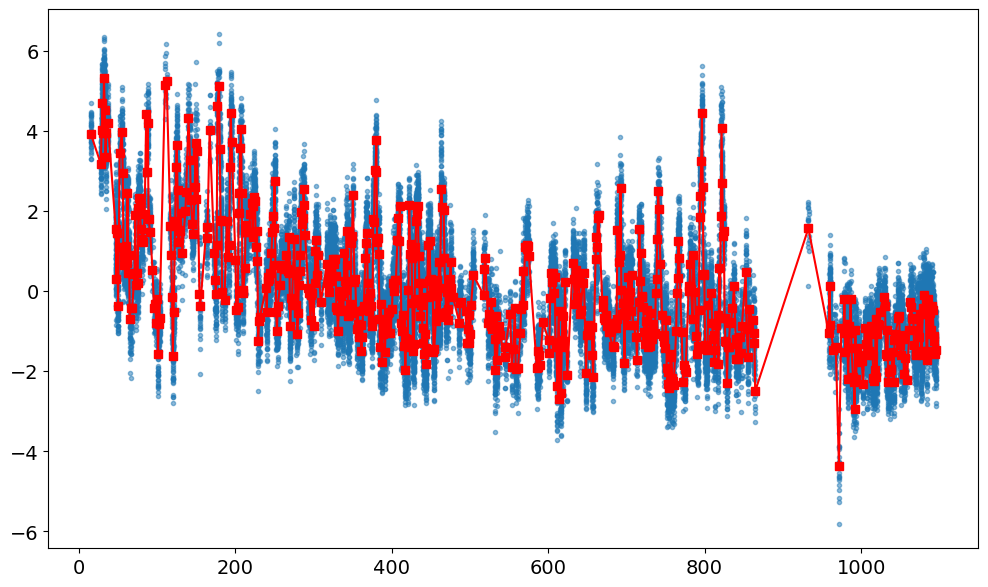

In [24]:
plt.plot(days_harps, rv_harps - np.mean(rv_harps), '.', alpha=0.5)
plt.plot(days_daily_avg, daily_avg.rv - np.mean(daily_avg.rv), 'sr-')
# plt.xlim(5,15)
plt.show()
np.savetxt('/home/sophie-stucki/Documents/starsim_simulations/harps/harps_rv_daily_averaged.txt', [days_daily_avg,  daily_avg.rv])

# plt.plot(daily_avg.date, daily_avg.bis - np.mean(daily_avg.bis), 'r')
# plt.plot(date_harps, bis_harps - np.mean(bis_harps), '.')

# plt.show()

# plt.plot(daily_avg.date, daily_avg.fwhm - np.mean(daily_avg.fwhm), 'r')
# plt.plot(date_harps, fwhm_harps - np.mean(fwhm_harps), '.')

# plt.show()

# plt.plot(daily_avg.date, daily_avg.contrast - np.mean(daily_avg.contrast), 'r')
# plt.plot(date_harps, contrast_harps - np.mean(contrast_harps), '.')

# plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/sophie-stucki/starsim/starsim/SDO_input/plots/3_years/comparison_spec.png'

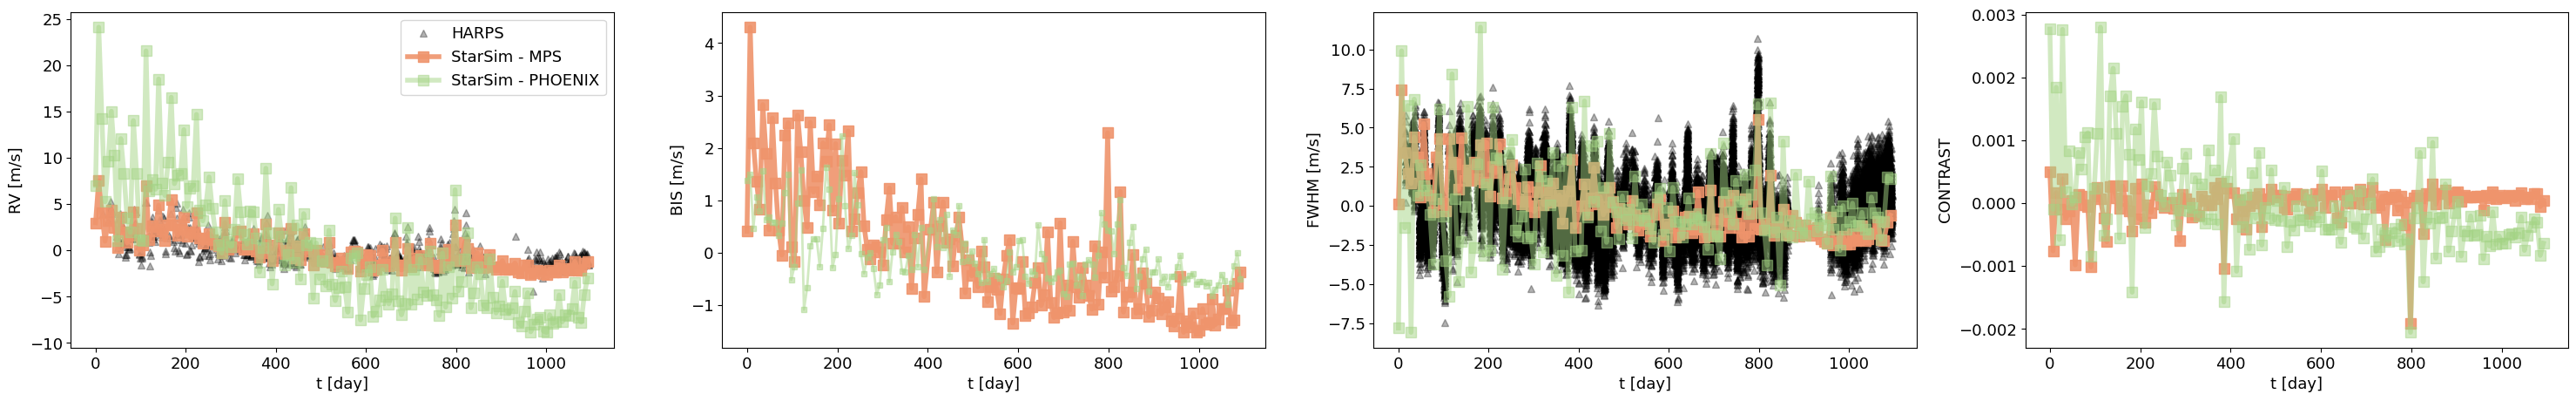

In [26]:
folder = '3_years'
rv_simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/{}/rv_test_mps.txt'.format(folder))
rv_simu_phoenix = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/{}/rv_test_phoenix.txt'.format(folder))
# rv_simu_stagger = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/{}/rv_test_stagger.txt'.format(folder))


bis_simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/{}/bis_test_mps.txt'.format(folder))
bis_simu_phoenix = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/{}/bis_test_phoenix.txt'.format(folder))

fwhm_simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/{}/fwhm_test_mps.txt'.format(folder))
fwhm_simu_phoenix = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/{}/fwhm_test_phoenix.txt'.format(folder))

cont_simu_mps = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/{}/cont_test_mps.txt'.format(folder))
cont_simu_phoenix = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/flux_output/{}/cont_test_phoenix.txt'.format(folder))

racoon_rv = pd.read_csv('/home/sophie-stucki/Documents/starsim_simulations/harps/rv.csv')
racoon_mps_rv = pd.read_csv('/home/sophie-stucki/Documents/starsim_simulations/harps/rv_mps_racoon.csv')

day_step = 7
# days_simu = np.loadtxt('/home/sophie-stucki/starsim/starsim/SDO_input/maps_satire/time.txt')
days_simu = days_simu = np.append(np.arange(57) * day_step, np.arange(58,157) * day_step)
# days_simu = range(365)


plt.rcParams['font.size'] = 13


fig, axs = plt.subplots(1,4, figsize=(37,5))

axs[0].plot( days_daily_avg,  daily_avg.rv - np.mean(daily_avg.rv),'^', label='HARPS', color="#000000", alpha =0.3)
axs[0].plot(days_simu, rv_simu_mps - np.mean(rv_simu_mps) ,'s-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9, markersize=8, linewidth=4)
axs[0].plot(days_simu, rv_simu_phoenix - np.mean(rv_simu_phoenix),'s-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.5, markersize=8, linewidth=4)
axs[0].set_xlabel('t [day]')
axs[0].set_ylabel('RV [m/s]')

# axs[1].plot( days_harps,  bis_harps - np.mean(bis_harps),'^', label='HARPS', color="#000000", alpha =0.3)
axs[1].plot(days_simu, bis_simu_mps - np.mean(bis_simu_mps) ,'s-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9, markersize=8, linewidth=4)
axs[1].plot(days_simu, bis_simu_phoenix - np.mean(bis_simu_phoenix),'s-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.5, markersize=4, linewidth=2)
axs[1].set_xlabel('t [day]')
axs[1].set_ylabel('BIS [m/s]')

axs[2].plot( days_harps,  fwhm_harps - np.mean(fwhm_harps),'^', label='HARPS', color="#000000", alpha =0.3)
axs[2].plot(days_simu, fwhm_simu_mps - np.mean(fwhm_simu_mps) ,'s-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9, markersize=8, linewidth=4)
axs[2].plot(days_simu, fwhm_simu_phoenix - np.mean(fwhm_simu_phoenix),'s-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.5,markersize=8, linewidth=4)
axs[2].set_xlabel('t [day]')
axs[2].set_ylabel('FWHM [m/s]')

# axs[3].plot( days_harps,  contrast_harps - np.mean(contrast_harps),'^', label='HARPS', color="#000000", alpha =0.3)
axs[3].plot(days_simu, cont_simu_mps - np.mean(cont_simu_mps) ,'s-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9, markersize=8, linewidth=4)
axs[3].plot(days_simu, cont_simu_phoenix - np.mean(cont_simu_phoenix),'s-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.5, markersize=8, linewidth=4)
axs[3].set_xlabel('t [day]')
axs[3].set_ylabel('CONTRAST')

axs[0].legend()
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/{}/comparison_spec.png'.format(folder),  dpi=300, bbox_inches='tight')
# plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/{}/comparison_spec_mean.png'.format(folder),  dpi=300, bbox_inches='tight')


plt.show()

In [27]:
# plt.rcParams['font.size'] = 8

# masks= np.isnan(racoon_rv.rv)

# # plt.plot( racoon_rv.days[~masks],  1e3 * (racoon_rv.rv[~masks] - np.mean(racoon_rv.rv[~masks])),'^-', label='HARPS-N- RACOON', color="#A764DA", alpha =0.4)

# # plt.plot( days_daily_avg,  daily_avg.rv - np.mean(daily_avg.rv),'^--', label='HARPS-N', color="#000000", alpha =0.3)
# plt.plot(days_simu, rv_simu_mps - np.mean(rv_simu_mps) ,'-', label = 'StarSim fit - MPS', color='#ef946c', alpha=0.9, markersize=5, linewidth=4)
# plt.plot(np.arange(0,62) , racoon_mps_rv.rv - np.mean(racoon_mps_rv.rv) ,'s', label = 'RACOON fit - MPS', color="#8ba6ff", alpha=0.9, markersize=5, linewidth=4)

# # plt.plot(days_simu, rv_simu_phoenix - np.mean(rv_simu_phoenix),'s-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.5, markersize=5, linewidth=4)
# plt.xlabel('t [day]')
# plt.ylabel('RV [m/s]')
# plt.legend()
# plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/{}/comparison_rv.png'.format(folder),  dpi=300, bbox_inches='tight')

# plt.show()

# for i, t in enumerate(days_daily_avg):
#     plt.plot(t, rv_simu_mps[int(t)] - np.mean(rv_simu_mps) - (daily_avg.rv[i] - np.mean(daily_avg.rv)),'s-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9, markersize=5, linewidth=4)
#     plt.plot(t, rv_simu_phoenix[int(t)] - np.mean(rv_simu_phoenix) - (daily_avg.rv[i] - np.mean(daily_avg.rv)),'s-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.5, markersize=5, linewidth=4)
# plt.xlabel('t [day]')
# plt.ylabel('Res RV [m/s]')
# # plt.legend()
# plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/home/sophie-stucki/starsim/starsim/SDO_input/plots/3_years/comparison_rv.png'

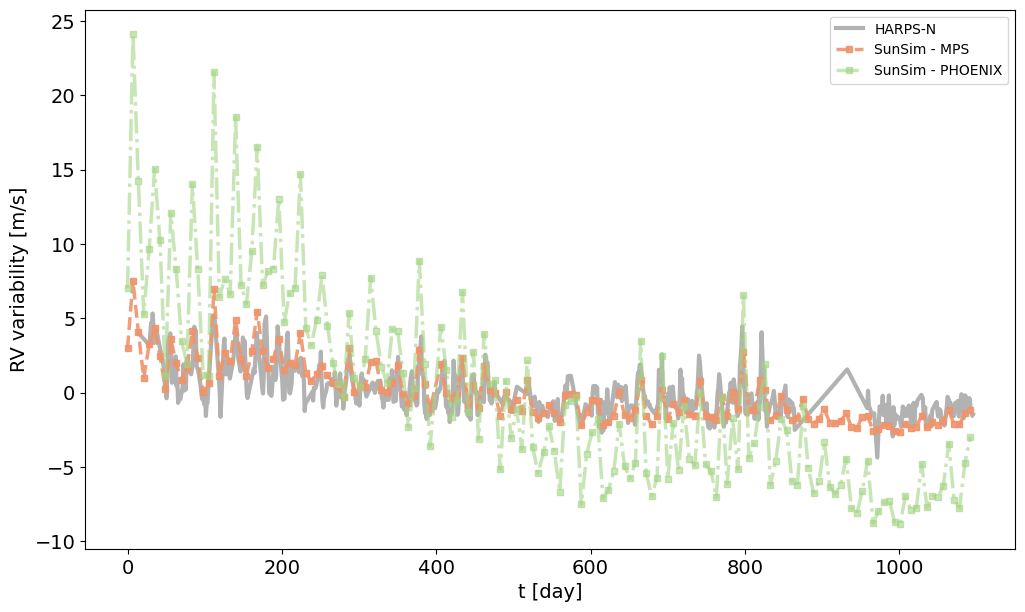

In [28]:
plt.rcParams['font.size'] = 14
plt.rcParams['figure.figsize'] = (12,7)
# plt.plot( racoon_rv.days[~masks], (racoon_rv.rv[~masks] - np.mean(racoon_rv.rv[~masks])) / np.max((racoon_rv.rv[~masks] - np.mean(racoon_rv.rv[~masks]))),'^-', label='HARPS-N- RACOON', color="#A764DA", alpha =0.4)
plt.plot( days_daily_avg,  (daily_avg.rv - np.mean(daily_avg.rv)),'', label='HARPS-N', color="#000000", alpha =0.3, linewidth=3)
plt.plot(days_simu, (rv_simu_mps - np.mean(rv_simu_mps)) ,'s--', label = 'SunSim - MPS', color='#ef946c', alpha=0.9, markersize=5, linewidth=2.5)
# plt.plot(days_simu, (rv_simu_stagger - np.mean(rv_simu_stagger)) / (np.max(rv_simu_stagger - np.mean(rv_simu_stagger))- np.min(rv_simu_stagger - np.mean(rv_simu_stagger))) ,'s-', label = 'SunSim - STAGGER', color="#ce9ffa", alpha=0.7, markersize=5, linewidth=2.5)
plt.plot(days_simu, (rv_simu_phoenix - np.mean(rv_simu_phoenix)) ,'s-.', label = 'SunSim - PHOENIX', color="#a4d485", alpha=0.6, markersize=5, linewidth=2.5)
plt.xlabel('t [day]')
plt.ylabel('RV variability [m/s]')
plt.legend(fontsize=10)
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/{}/comparison_rv.png'.format(folder),  dpi=300, bbox_inches='tight')

plt.show()
plt.plot( days_daily_avg,  (daily_avg.rv - np.mean(daily_avg.rv)) / (np.max( daily_avg.rv - np.mean(daily_avg.rv)) - np.min( daily_avg.rv - np.mean(daily_avg.rv))),'', label='HARPS-N', color="#000000", alpha =0.3, linewidth=3)
plt.plot(days_simu, (rv_simu_mps - np.mean(rv_simu_mps)) / (np.max(rv_simu_mps - np.mean(rv_simu_mps))- np.min(rv_simu_mps - np.mean(rv_simu_mps))) ,'s-', label = 'SunSim - MPS', color='#ef946c', alpha=0.9, markersize=5, linewidth=2.5)
# plt.plot(days_simu, (rv_simu_stagger - np.mean(rv_simu_stagger)) / (np.max(rv_simu_stagger - np.mean(rv_simu_stagger))- np.min(rv_simu_stagger - np.mean(rv_simu_stagger))) ,'s-', label = 'SunSim - STAGGER', color="#ce9ffa", alpha=0.7, markersize=5, linewidth=2.5)
plt.plot(days_simu, (rv_simu_phoenix - np.mean(rv_simu_phoenix)) / (np.max(rv_simu_phoenix - np.mean(rv_simu_phoenix))- np.min(rv_simu_phoenix - np.mean(rv_simu_phoenix))),'s-', label = 'SunSim - PHOENIX', color="#a4d485", alpha=0.6, markersize=5, linewidth=2.5)
plt.xlabel('t [day]')
plt.ylabel('normalized RV variability')
plt.legend(fontsize=10)
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/{}/comparison_rv_shape.png'.format(folder),  dpi=300, bbox_inches='tight')

plt.show()

# plt.plot(days_simu, (rv_simu_stagger - np.mean(rv_simu_stagger)) ,'s-', label = 'SunSim - STAGGER', color="#ce9ffa", alpha=0.7, markersize=5, linewidth=2.5)
# plt.plot(days_simu, (rv_simu_phoenix - np.mean(rv_simu_phoenix)) ,'s-', label = 'SunSim - PHOENIX', color="#a4d485", alpha=0.6, markersize=5, linewidth=2.5)
# plt.xlabel('t [day]')
# plt.ylabel('RV variability [m/s]')
# plt.legend(fontsize=10)
# plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/{}/comparison_rv_stagger.png'.format(folder),  dpi=300, bbox_inches='tight')

# plt.show()

# for i, t in enumerate(days_daily_avg):
#     plt.plot(t, rv_simu_mps[int(t)] - np.mean(rv_simu_mps) - (daily_avg.rv[i] - np.mean(daily_avg.rv)),'s-', label = 'StarSim - MPS', color='#ef946c', alpha=0.9, markersize=5, linewidth=4)
#     plt.plot(t, rv_simu_phoenix[int(t)] - np.mean(rv_simu_phoenix) - (daily_avg.rv[i] - np.mean(daily_avg.rv)),'s-', label = 'StarSim - PHOENIX', color="#a4d485", alpha=0.5, markersize=5, linewidth=4)
# plt.xlabel('t [day]')
# plt.ylabel('Res RV [m/s]')
# # plt.legend()
# plt.show()

2.1831982193874997


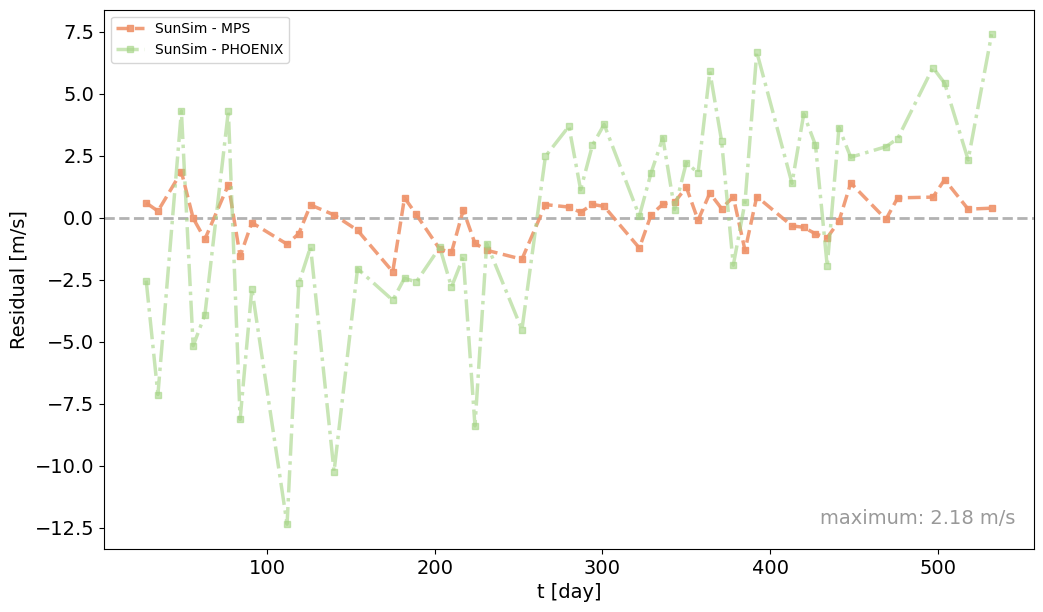

In [45]:
idx_h = []
idx = []

for k, d in enumerate(days_simu):
    i = np.argwhere(np.array(days_daily_avg)-0.5==d)
    if len(i) > 0:
        idx_h.append(i)
        idx.append(k)

idx_h = np.squeeze(idx_h)
idx = np.squeeze(idx)

days_simu = np.array(days_simu)

plt.axhline(0, linestyle= '--', color="#000000", alpha =0.3, linewidth=2 )

plt.plot(days_simu[idx],  (daily_avg.rv[idx_h] - np.mean(daily_avg.rv[idx_h])) - (rv_simu_mps[idx] - np.mean(rv_simu_mps[idx])) ,'s--', label = 'SunSim - MPS', color='#ef946c', alpha=0.9, markersize=5, linewidth=2.5)
plt.plot(days_simu[idx], (daily_avg.rv[idx_h] - np.mean(daily_avg.rv[idx_h])) - (rv_simu_phoenix[idx] - np.mean(rv_simu_phoenix[idx])) ,'s-.', label = 'SunSim - PHOENIX', color="#a4d485", alpha=0.6, markersize=5, linewidth=2.5)
plt.xlabel('t [day]')
plt.ylabel('Residual [m/s]')
plt.legend(fontsize=10)
plt.text(days_simu[-1]/2, np.min((daily_avg.rv[idx_h] - np.mean(daily_avg.rv[idx_h])) - (rv_simu_phoenix[idx] - np.mean(rv_simu_phoenix[idx]))), 'maximum: {:.2f} m/s'.format(np.max( np.abs((daily_avg.rv[idx_h] - np.mean(daily_avg.rv[idx_h])) - (rv_simu_mps[idx] - np.mean(rv_simu_mps[idx]))))), alpha=0.4, horizontalalignment='right')
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/{}/res_comparison_rv.png'.format(folder),  dpi=300, bbox_inches='tight')

print(np.max( np.abs((daily_avg.rv[idx_h] - np.mean(daily_avg.rv[idx_h])) - (rv_simu_mps[idx] - np.mean(rv_simu_mps[idx])))))

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.size'] = 25

def match_yaxis_range_and_ticks(ax1, ax2, data1, data2, num_ticks=5):
    min1, max1 = np.min(data1), np.max(data1)
    min2, max2 = np.min(data2), np.max(data2)

    span1 = max1 - min1
    span2 = max2 - min2
    full_span = max(span1, span2)

    pad = 0.05 * full_span
    full_span += 2 * pad

    center1 = (max1 + min1) / 2
    center2 = (max2 + min2) / 2

    ax1.set_ylim(center1 - full_span / 2, center1 + full_span / 2)
    ax2.set_ylim(center2 - full_span / 2, center2 + full_span / 2)

    ticks1 = np.linspace(center1 - full_span / 2, center1 + full_span / 2, num_ticks)
    ticks2 = np.linspace(center2 - full_span / 2, center2 + full_span / 2, num_ticks)

    ax1.set_yticks(ticks1)
    ax2.set_yticks(ticks2)


# === Load your data here ===
# Replace the following lines with your actual data variables:
# Example placeholders:
# days_simu = np.array([...])
# rv_simu_mps = np.array([...])
# rv_simu_phoenix = np.array([...])
# bis_simu_mps = np.array([...])
# bis_simu_phoenix = np.array([...])
# fwhm_simu_mps = np.array([...])
# fwhm_simu_phoenix = np.array([...])
# cont_simu_mps = np.array([...])
# cont_simu_phoenix = np.array([...])

# -------------------
# RV plot
fig, ax0 = plt.subplots(figsize=(8, 5))
ax0b = ax0

# ax0.plot(days_simu, rv_simu_mps, 's-', label='StarSim - MPS', color='#ef946c', alpha=0.9, markersize=4, linewidth=2)
ax0b.plot(days_simu, rv_simu_phoenix, 's-', label='SunSim: PHOENIX', color='#a4d485', alpha=1, markersize=4, linewidth=2)

ax0.set_xlabel('t [day]')
ax0.set_ylabel('RV [m/s]')
# ax0b.spines['right'].set_position(('axes', 1))
# ax0b.tick_params(axis='y', labelcolor='#a4d485')
# ax0.tick_params(axis='y', labelcolor='#ef946c')

# match_yaxis_range_and_ticks(ax0, ax0b, rv_simu_mps, rv_simu_phoenix)

lines1, labels1 = ax0.get_legend_handles_labels()
lines2, labels2 = ax0b.get_legend_handles_labels()
# ax0.legend(lines1 + lines2, labels1 + labels2, loc='best')
ax0.legend(fontsize=20)

plt.tight_layout()
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/{}/comparison_spec_RV.png'.format(folder), dpi=300, bbox_inches='tight', transparent=True)
plt.close()


# -------------------
# BIS plot
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1b = ax1.twinx()

ax1.plot(days_simu, bis_simu_mps , 's-', label='StarSim - MPS', color='#ef946c', alpha=0.9, markersize=4, linewidth=2)
ax1b.plot(days_simu, bis_simu_phoenix , 's-', label='StarSim - PHOENIX', color='#a4d485', alpha=0.5, markersize=4, linewidth=2)

ax1.set_xlabel('t [day]')
ax1.set_ylabel('BIS [m/s]')
ax1b.spines['right'].set_position(('axes', 1))
ax1b.tick_params(axis='y', labelcolor='#a4d485')
ax1.tick_params(axis='y', labelcolor='#ef946c')

match_yaxis_range_and_ticks(ax1, ax1b, bis_simu_mps, bis_simu_phoenix)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
# ax1.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/{}/comparison_spec_BIS.png'.format(folder), dpi=300, bbox_inches='tight', transparent=True)
plt.close()


# -------------------
# FWHM plot
fig, ax2 = plt.subplots(figsize=(8, 5))
ax2b = ax2.twinx()

ax2.plot(days_simu, fwhm_simu_mps, 's-', label='StarSim - MPS', color='#ef946c', alpha=0.9, markersize=4, linewidth=2)
ax2b.plot(days_simu, fwhm_simu_phoenix, 's-', label='StarSim - PHOENIX', color='#a4d485', alpha=0.5, markersize=4, linewidth=2)

ax2.set_xlabel('t [day]')
ax2.set_ylabel('FWHM [m/s]')
ax2b.spines['right'].set_position(('axes', 1))
ax2b.tick_params(axis='y', labelcolor='#a4d485')
ax2.tick_params(axis='y', labelcolor='#ef946c')

match_yaxis_range_and_ticks(ax2, ax2b, fwhm_simu_mps, fwhm_simu_phoenix)

lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
# ax2.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/{}/comparison_spec_FWHM.png'.format(folder), dpi=300, bbox_inches='tight', transparent=True)
plt.close()


# -------------------
# CONTRAST plot
fig, ax3 = plt.subplots(figsize=(8, 5))
ax3b = ax3.twinx()

ax3.plot(days_simu, cont_simu_mps, 's-', label='StarSim - MPS', color='#ef946c', markersize=4, linewidth=2)
ax3b.plot(days_simu, cont_simu_phoenix, 's-', label='StarSim - PHOENIX', color='#a4d485', markersize=4, linewidth=2)

ax3.set_xlabel('t [day]')
ax3.set_ylabel('CONTRAST')
ax3b.spines['right'].set_position(('axes', 1))
ax3b.tick_params(axis='y', labelcolor='#a4d485')
ax3.tick_params(axis='y', labelcolor='#ef946c')

match_yaxis_range_and_ticks(ax3, ax3b, cont_simu_mps, cont_simu_phoenix)

lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1 + lines2, labels1 + labels2, loc='best')

plt.tight_layout()
plt.savefig('/home/sophie-stucki/starsim/starsim/SDO_input/plots/{}/comparison_spec_CONTRAST.png'.format(folder), dpi=300, bbox_inches='tight', transparent=True)
plt.close()


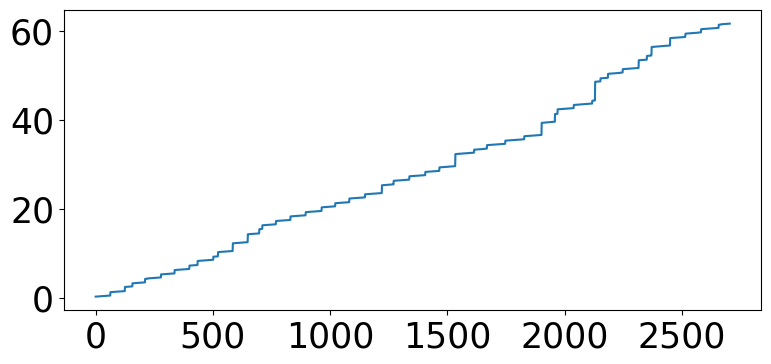

In [ ]:
plt.plot(np.sort(days_harps))